<a href="https://colab.research.google.com/github/moongoldpk/Adidas-US-Sales-Dataset-Analysis/blob/main/Adidas_US_Sales_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructions for Data Analysis and Model Implementation
## Adidas US Sales Dataset Analysis

In [14]:
# Required Python Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully!')

All libraries imported successfully!


In [15]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("heemalichaudhari/adidas-sales-dataset")
# Look for the file (likely an Excel file)
files = os.listdir(path)
print("Files:", files)
file_path = os.path.join(path, files[0])  # assume first file

# Load the Excel file, using row 3 (0-indexed) as a potential header start
df = pd.read_excel(file_path, header=3)
df_raw = df

# The actual column names are in the first row of the loaded DataFrame (index 0)
# Explicitly convert to string and strip, and remove name to avoid MultiIndex issues
new_columns = df.iloc[0].astype(str).str.strip()
new_columns.name = None # Ensure the index doesn't have a name that could cause issues
df.columns = new_columns
df = df.iloc[1:].reset_index(drop=True) # Drop the redundant header row from the data

# Re-strip any whitespace from column names, ensuring they are simple strings
df.columns = df.columns.astype(str).str.strip()

# Drop any columns that are entirely empty (e.g., the original 'Unnamed: 0' if it contained NaN)
df = df.dropna(axis=1, how='all')

df.head()

Using Colab cache for faster access to the 'adidas-sales-dataset' dataset.
Files: ['Adidas US Sales Datasets.xlsx', '.nfs0000000077c4bef600000044']


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01 00:00:00,Northeast,New York,New York,Men's Street Footwear,50,1200,600000,300000,0.5,In-store
1,Foot Locker,1185732,2020-01-02 00:00:00,Northeast,New York,New York,Men's Athletic Footwear,50,1000,500000,150000,0.3,In-store
2,Foot Locker,1185732,2020-01-03 00:00:00,Northeast,New York,New York,Women's Street Footwear,40,1000,400000,140000,0.35,In-store
3,Foot Locker,1185732,2020-01-04 00:00:00,Northeast,New York,New York,Women's Athletic Footwear,45,850,382500,133875,0.35,In-store
4,Foot Locker,1185732,2020-01-05 00:00:00,Northeast,New York,New York,Men's Apparel,60,900,540000,162000,0.3,In-store


---
# 1. Data Understanding and Exploratory Data Analysis (EDA)

The first task is to explore the dataset and produce descriptive statistics and visual insights.

## 1.1 Descriptive Statistics

Calculate the following statistics for key numerical variables (e.g., Price per Unit, Units Sold) and make appropriate visualizations.
- Mean
- Median
- Standard Deviation
- Minimum value
- Maximum value

In [16]:
# === SAFE DESCRIPTIVE STATISTICS ===

# 1. Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# 2. Define the columns we want
desired_cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']

# 3. Find which of these actually exist in the DataFrame
existing_cols = [col for col in desired_cols if col in df.columns]

# 4. If none exist, print the actual column names to help debug
if not existing_cols:
    print("❌ None of the expected columns were found.")
    print("🔍 Here are the actual columns in your dataset:")
    print(df.columns.tolist())
else:
    print(f"✅ Found these columns: {existing_cols}")

    # 5. Compute descriptive statistics
    desc_stats = df[existing_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
    desc_stats.columns = ['Mean', 'Median', 'Standard Deviation', 'Minimum', 'Maximum']
    desc_stats = desc_stats.round(2)

    print('\nDescriptive Statistics for Key Numerical Variables')
    print('=' * 65)
    print(desc_stats.to_string())

✅ Found these columns: ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']

Descriptive Statistics for Key Numerical Variables
                      Mean   Median  Standard Deviation  Minimum   Maximum
Price per Unit       45.22    45.00               14.71      7.0     110.0
Units Sold          256.93   176.00              214.25      0.0    1275.0
Total Sales       93273.44  9576.00           141916.02      0.0  825000.0
Operating Profit  34425.24  4371.42            54193.11      0.0  390000.0
Operating Margin      0.42     0.41                0.10      0.1       0.8


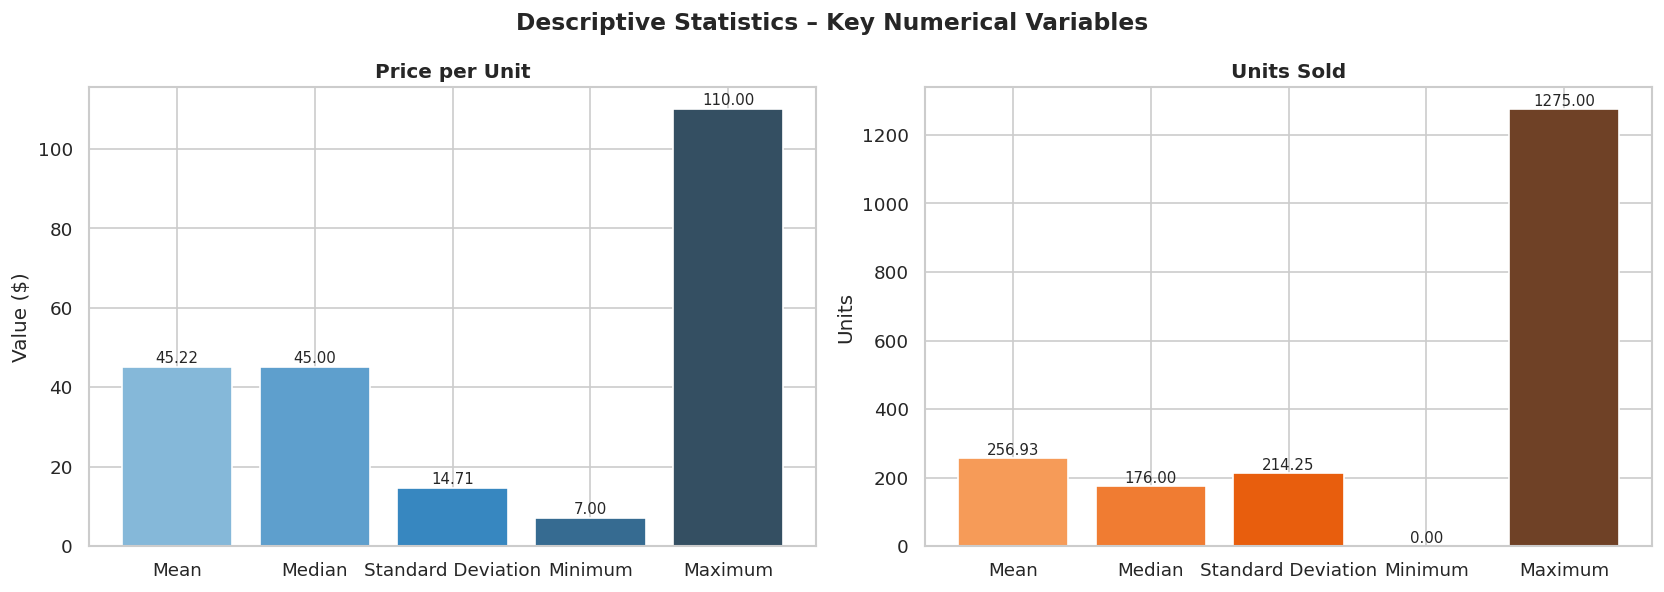

Descriptive statistics visualization saved.


In [17]:
# Visualisation of Descriptive Statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Descriptive Statistics – Key Numerical Variables', fontsize=14, fontweight='bold')

# Price per Unit
price_stats = desc_stats.loc['Price per Unit']
bars1 = axes[0].bar(price_stats.index, price_stats.values, color=sns.color_palette('Blues_d', 5))
axes[0].set_title('Price per Unit', fontweight='bold')
axes[0].set_ylabel('Value ($)')
for bar, val in zip(bars1, price_stats.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=9)

# Units Sold
units_stats = desc_stats.loc['Units Sold']
bars2 = axes[1].bar(units_stats.index, units_stats.values, color=sns.color_palette('Oranges_d', 5))
axes[1].set_title('Units Sold', fontweight='bold')
axes[1].set_ylabel('Units')
for bar, val in zip(bars2, units_stats.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('descriptive_stats.png', bbox_inches='tight')
plt.show()
print('Descriptive statistics visualization saved.')

## 1.2 Visualisations to Produce

### Figure 1 – Sales Distribution
Histogram showing distribution of **Units Sold**

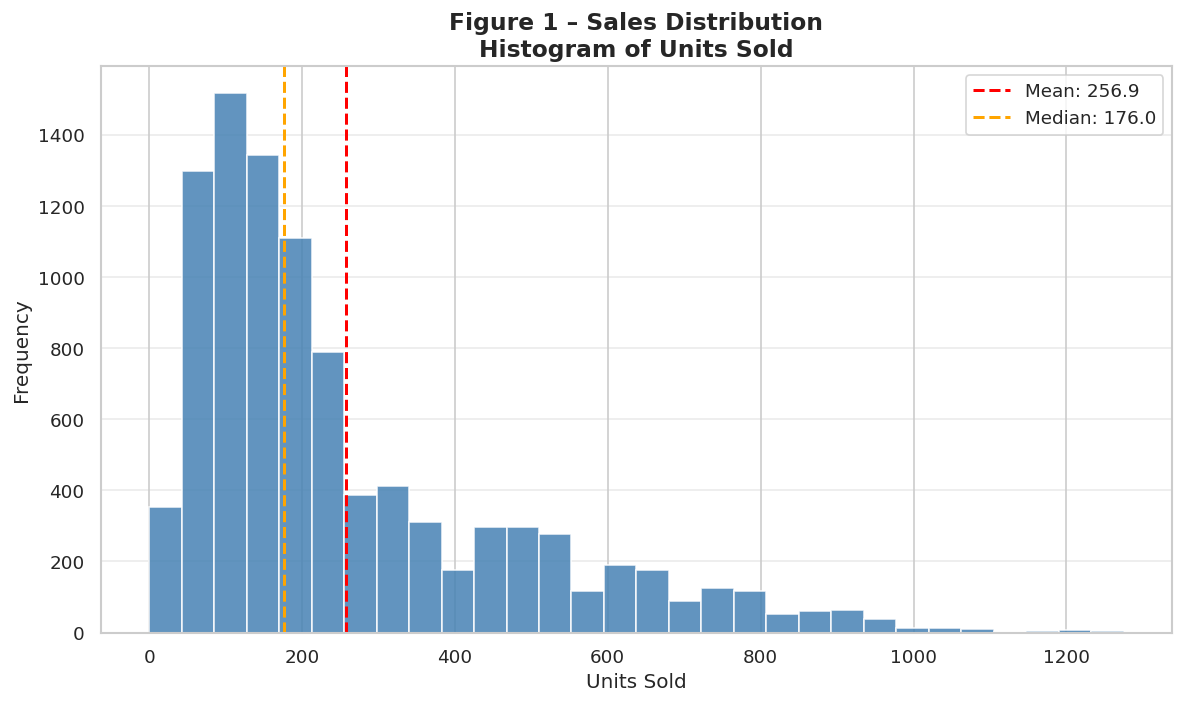

Figure 1 saved.


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

# ✅ CHANGE: df_raw -> df
ax.hist(df['Units Sold'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['Units Sold'].mean(), color='red', linestyle='--', linewidth=1.8, label=f"Mean: {df['Units Sold'].mean():.1f}")
ax.axvline(df['Units Sold'].median(), color='orange', linestyle='--', linewidth=1.8, label=f"Median: {df['Units Sold'].median():.1f}")

ax.set_title('Figure 1 – Sales Distribution\nHistogram of Units Sold', fontsize=14, fontweight='bold')
ax.set_xlabel('Units Sold', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figure1_sales_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

### Figure 2 – Region-wise Sales
Bar chart showing **total sales by region**

Must include: Region, Product, City, State

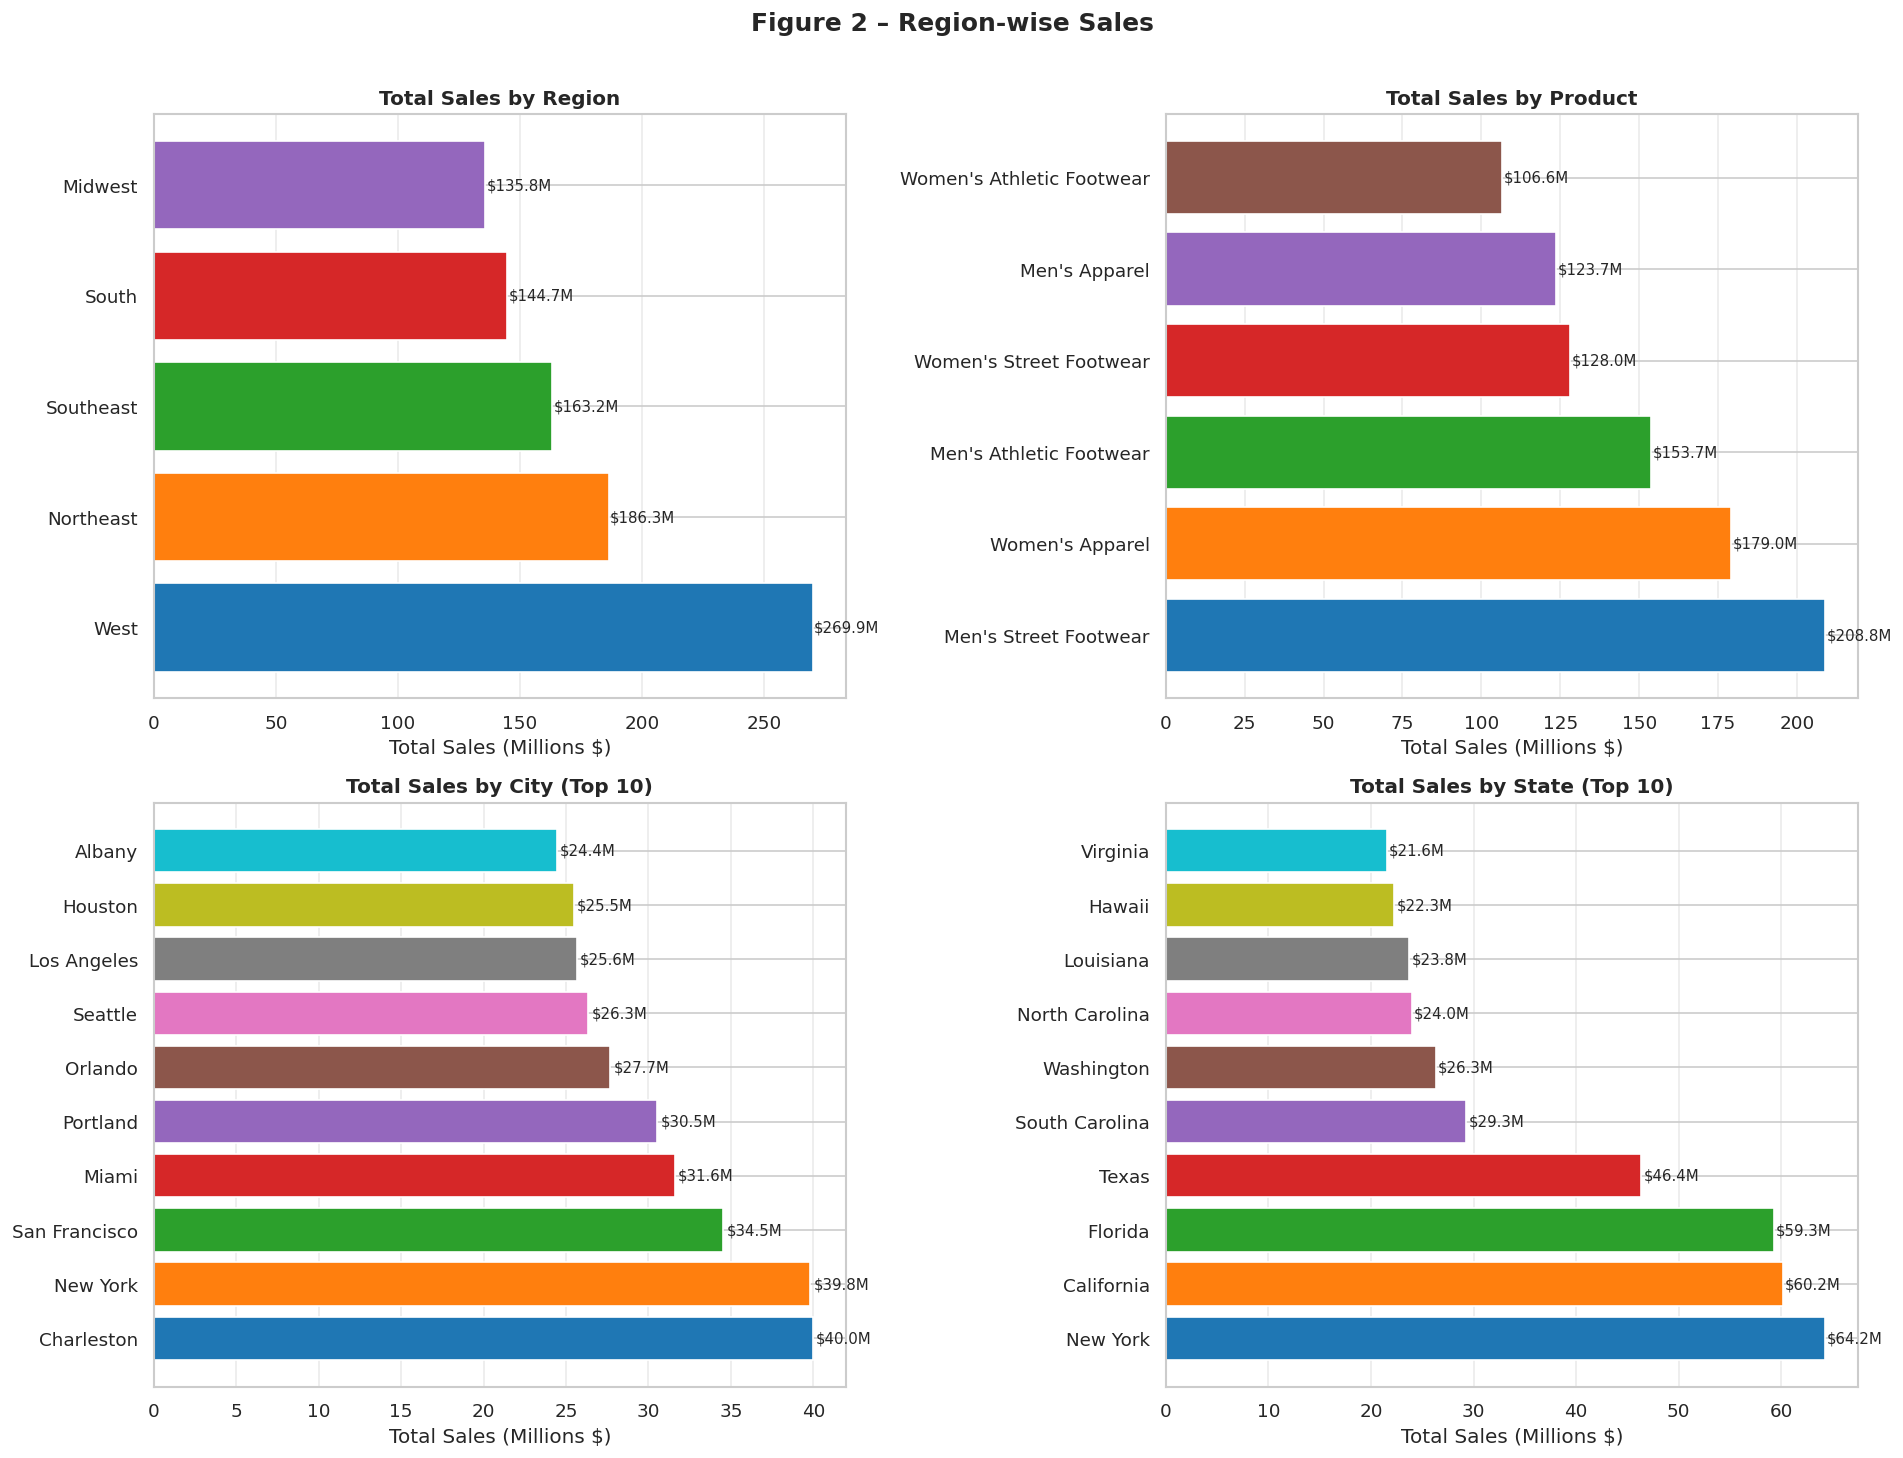

Figure 2 saved.


In [20]:
# === CLEANING STEP (run once, before any grouping) ===
numeric_cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# If your code uses df_raw, create alias
df_raw = df

# === FIGURE 2: Region-wise Sales ===
region_sales = df_raw.groupby('Region')['Total Sales'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Figure 2 – Region-wise Sales', fontsize=15, fontweight='bold', y=1.01)

palette = sns.color_palette('tab10')

# Region
ax1 = axes[0, 0]
bars = ax1.barh(region_sales['Region'], region_sales['Total Sales'] / 1e6, color=palette[:len(region_sales)])
ax1.set_title('Total Sales by Region', fontweight='bold')
ax1.set_xlabel('Total Sales (Millions $)')
for bar in bars:
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():.1f}M', va='center', fontsize=9)
ax1.grid(axis='x', alpha=0.4)

# Product
ax2 = axes[0, 1]
prod_sales = df_raw.groupby('Product')['Total Sales'].sum().sort_values(ascending=False).reset_index()
bars2 = ax2.barh(prod_sales['Product'], prod_sales['Total Sales'] / 1e6, color=palette[:len(prod_sales)])
ax2.set_title('Total Sales by Product', fontweight='bold')
ax2.set_xlabel('Total Sales (Millions $)')
for bar in bars2:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():.1f}M', va='center', fontsize=9)
ax2.grid(axis='x', alpha=0.4)

# City (Top 10)
ax3 = axes[1, 0]
city_sales = df_raw.groupby('City')['Total Sales'].sum().sort_values(ascending=False).head(10).reset_index()
bars3 = ax3.barh(city_sales['City'], city_sales['Total Sales'] / 1e6, color=palette[:10])
ax3.set_title('Total Sales by City (Top 10)', fontweight='bold')
ax3.set_xlabel('Total Sales (Millions $)')
for bar in bars3:
    ax3.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():.1f}M', va='center', fontsize=9)
ax3.grid(axis='x', alpha=0.4)

# State (Top 10)
ax4 = axes[1, 1]
state_sales = df_raw.groupby('State')['Total Sales'].sum().sort_values(ascending=False).head(10).reset_index()
bars4 = ax4.barh(state_sales['State'], state_sales['Total Sales'] / 1e6, color=palette[:10])
ax4.set_title('Total Sales by State (Top 10)', fontweight='bold')
ax4.set_xlabel('Total Sales (Millions $)')
for bar in bars4:
    ax4.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():.1f}M', va='center', fontsize=9)
ax4.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('figure2_region_wise_sales.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

### Figure 3 – Product Performance
Bar chart comparing **total units sold per product**

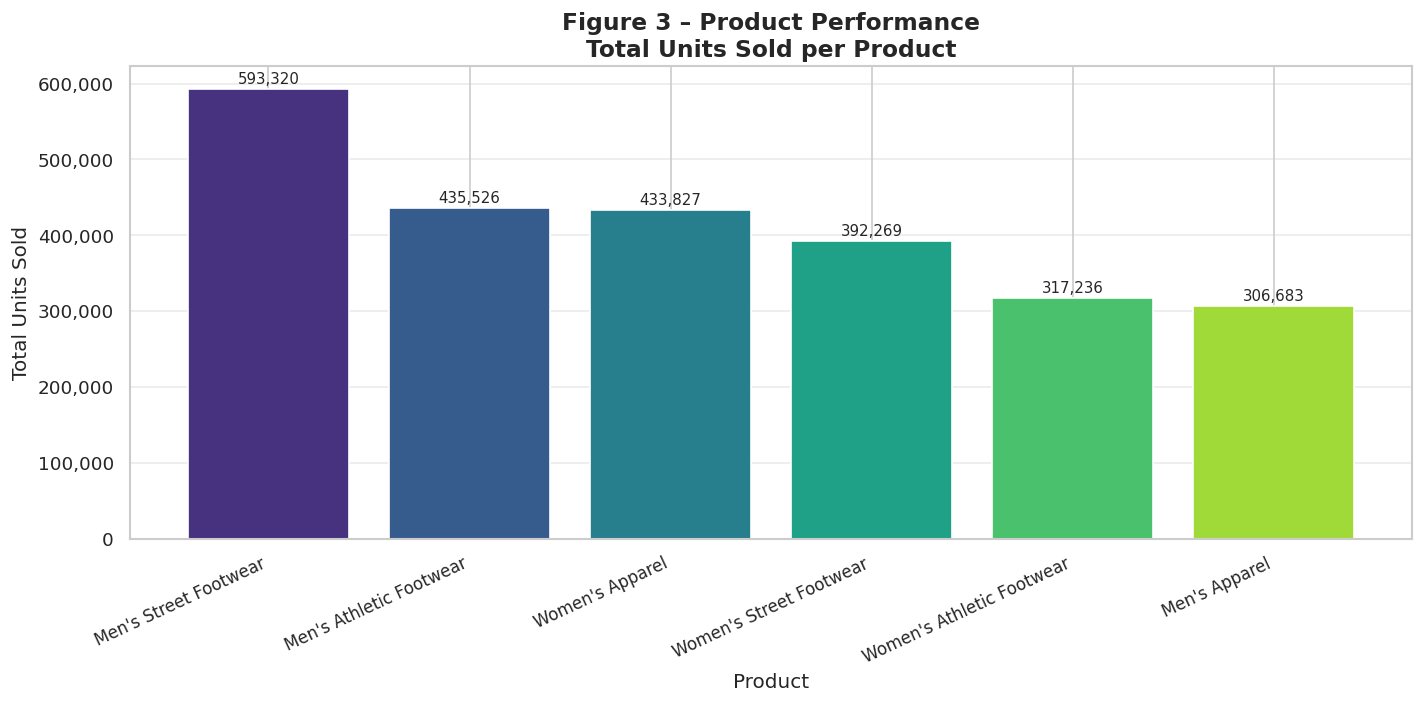

Figure 3 saved.


In [21]:
product_units = df_raw.groupby('Product')['Units Sold'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(product_units))
bars = ax.bar(product_units['Product'], product_units['Units Sold'], color=colors, edgecolor='white')

ax.set_title('Figure 3 – Product Performance\nTotal Units Sold per Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Product', fontsize=12)
ax.set_ylabel('Total Units Sold', fontsize=12)
ax.set_xticklabels(product_units['Product'], rotation=25, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figure3_product_performance.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

### Figure 4 – Price vs Units Sold
Scatter plot showing the relationship between **Price per Unit and Units Sold**

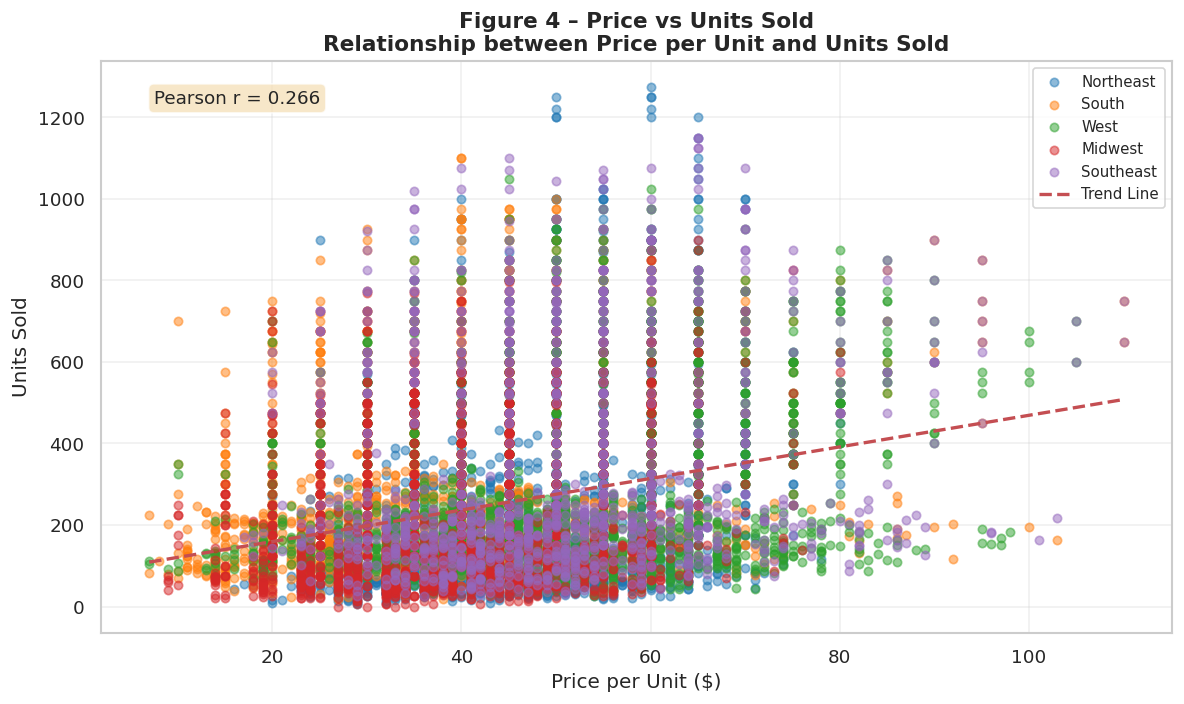

Figure 4 saved.


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- FIX: Convert columns to numeric and drop NaN ---
df_clean = df_raw.copy()
df_clean['Price per Unit'] = pd.to_numeric(df_clean['Price per Unit'], errors='coerce')
df_clean['Units Sold'] = pd.to_numeric(df_clean['Units Sold'], errors='coerce')
df_plot = df_clean.dropna(subset=['Price per Unit', 'Units Sold'])

# Color by Region
regions = df_plot['Region'].unique()
palette = sns.color_palette('tab10', len(regions))
region_color = {r: c for r, c in zip(regions, palette)}

for region in regions:
    subset = df_plot[df_plot['Region'] == region]
    ax.scatter(subset['Price per Unit'], subset['Units Sold'],
               alpha=0.5, s=25, label=region, color=region_color[region])

# Trend line (using cleaned data)
z = np.polyfit(df_plot['Price per Unit'], df_plot['Units Sold'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_plot['Price per Unit'].min(), df_plot['Price per Unit'].max(), 200)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')

ax.set_title('Figure 4 – Price vs Units Sold\nRelationship between Price per Unit and Units Sold', fontsize=13, fontweight='bold')
ax.set_xlabel('Price per Unit ($)', fontsize=12)
ax.set_ylabel('Units Sold', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

# Correlation annotation
corr = df_plot['Price per Unit'].corr(df_plot['Units Sold'])
ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('figure4_price_vs_units.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

### Figure 5 – Most Selling Product

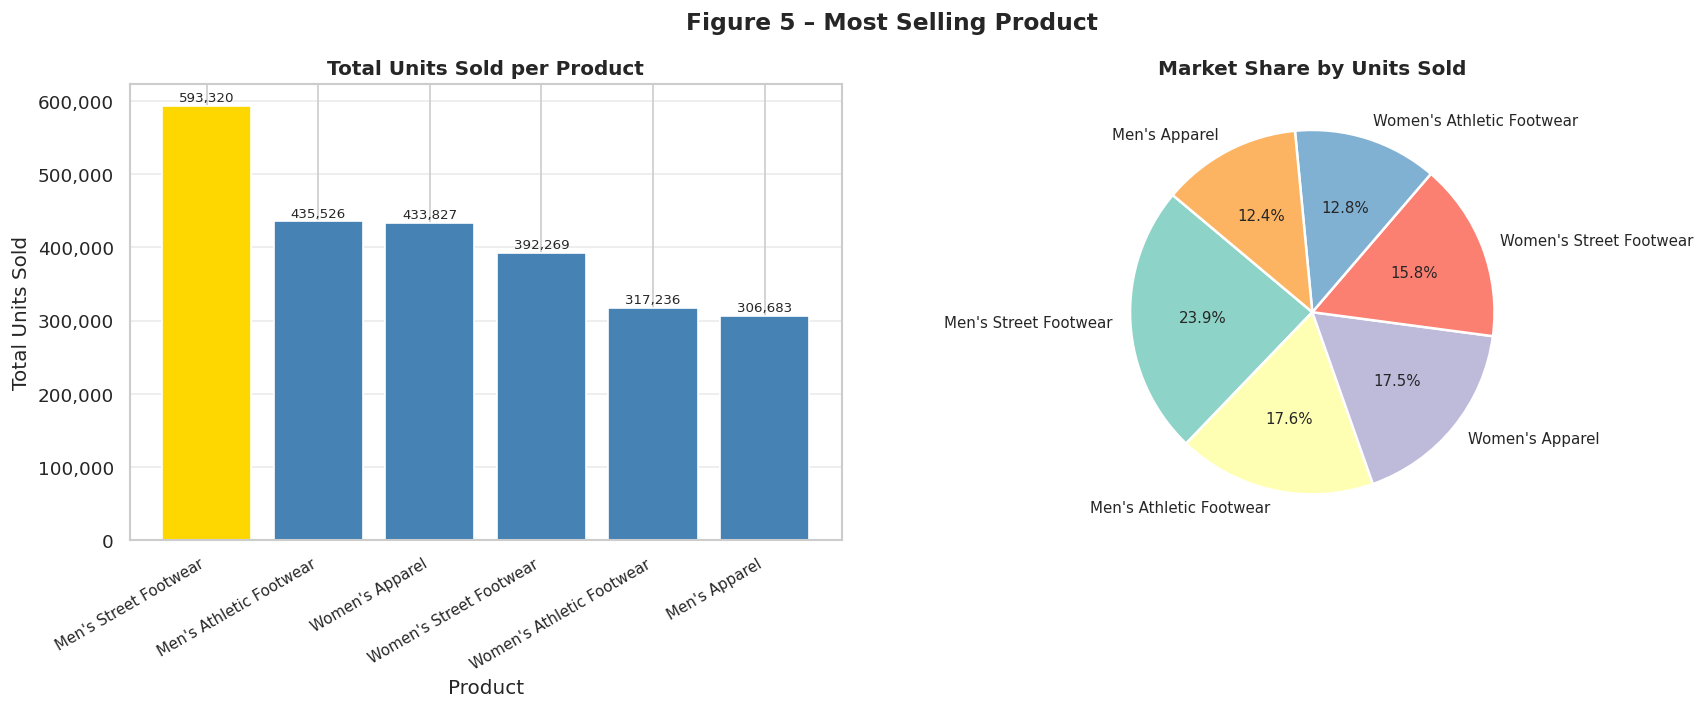

Most selling product: Men's Street Footwear with 593,320 units sold.
Figure 5 saved.


In [23]:
most_selling = df_raw.groupby('Product')['Units Sold'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 5 – Most Selling Product', fontsize=14, fontweight='bold')

# Bar chart
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(most_selling))]
bars = axes[0].bar(most_selling['Product'], most_selling['Units Sold'], color=colors, edgecolor='white')
axes[0].set_title('Total Units Sold per Product', fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Total Units Sold')
axes[0].set_xticklabels(most_selling['Product'], rotation=30, ha='right', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
axes[0].grid(axis='y', alpha=0.4)

# Pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
axes[1].pie(most_selling['Units Sold'], labels=most_selling['Product'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set3', len(most_selling)),
            wedgeprops=wedge_props, textprops={'fontsize': 9})
axes[1].set_title('Market Share by Units Sold', fontweight='bold')

plt.tight_layout()
plt.savefig('figure5_most_selling_product.png', bbox_inches='tight')
plt.show()
top_product = most_selling.iloc[0]
print(f'Most selling product: {top_product["Product"]} with {int(top_product["Units Sold"]):,} units sold.')
print('Figure 5 saved.')

### Figure 6 – Operating Profit and Operating Margin

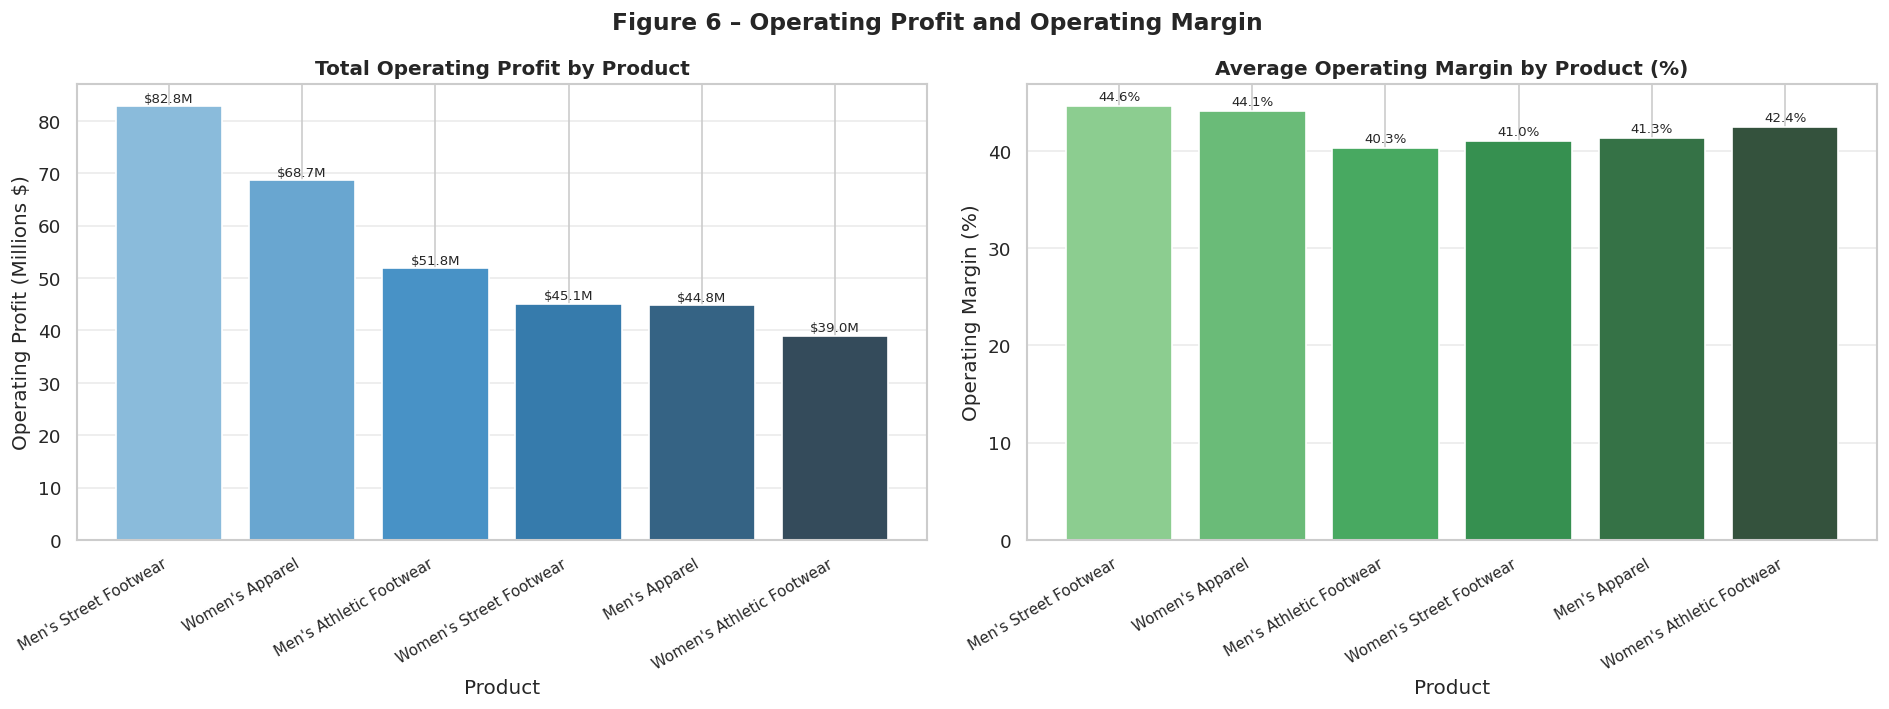

Figure 6 saved.


In [24]:
op_data = df_raw.groupby('Product').agg(
    Operating_Profit=('Operating Profit', 'sum'),
    Operating_Margin=('Operating Margin', 'mean')
).reset_index().sort_values('Operating_Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 6 – Operating Profit and Operating Margin', fontsize=14, fontweight='bold')

# Operating Profit
bars1 = axes[0].bar(op_data['Product'], op_data['Operating_Profit'] / 1e6,
                    color=sns.color_palette('Blues_d', len(op_data)), edgecolor='white')
axes[0].set_title('Total Operating Profit by Product', fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Operating Profit (Millions $)')
axes[0].set_xticklabels(op_data['Product'], rotation=30, ha='right', fontsize=9)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'${bar.get_height():.1f}M', ha='center', va='bottom', fontsize=8)
axes[0].grid(axis='y', alpha=0.4)

# Operating Margin
bars2 = axes[1].bar(op_data['Product'], op_data['Operating_Margin'] * 100,
                    color=sns.color_palette('Greens_d', len(op_data)), edgecolor='white')
axes[1].set_title('Average Operating Margin by Product (%)', fontweight='bold')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Operating Margin (%)')
axes[1].set_xticklabels(op_data['Product'], rotation=30, ha='right', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figure6_operating_profit_margin.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

### Figure 7 – Sales Method

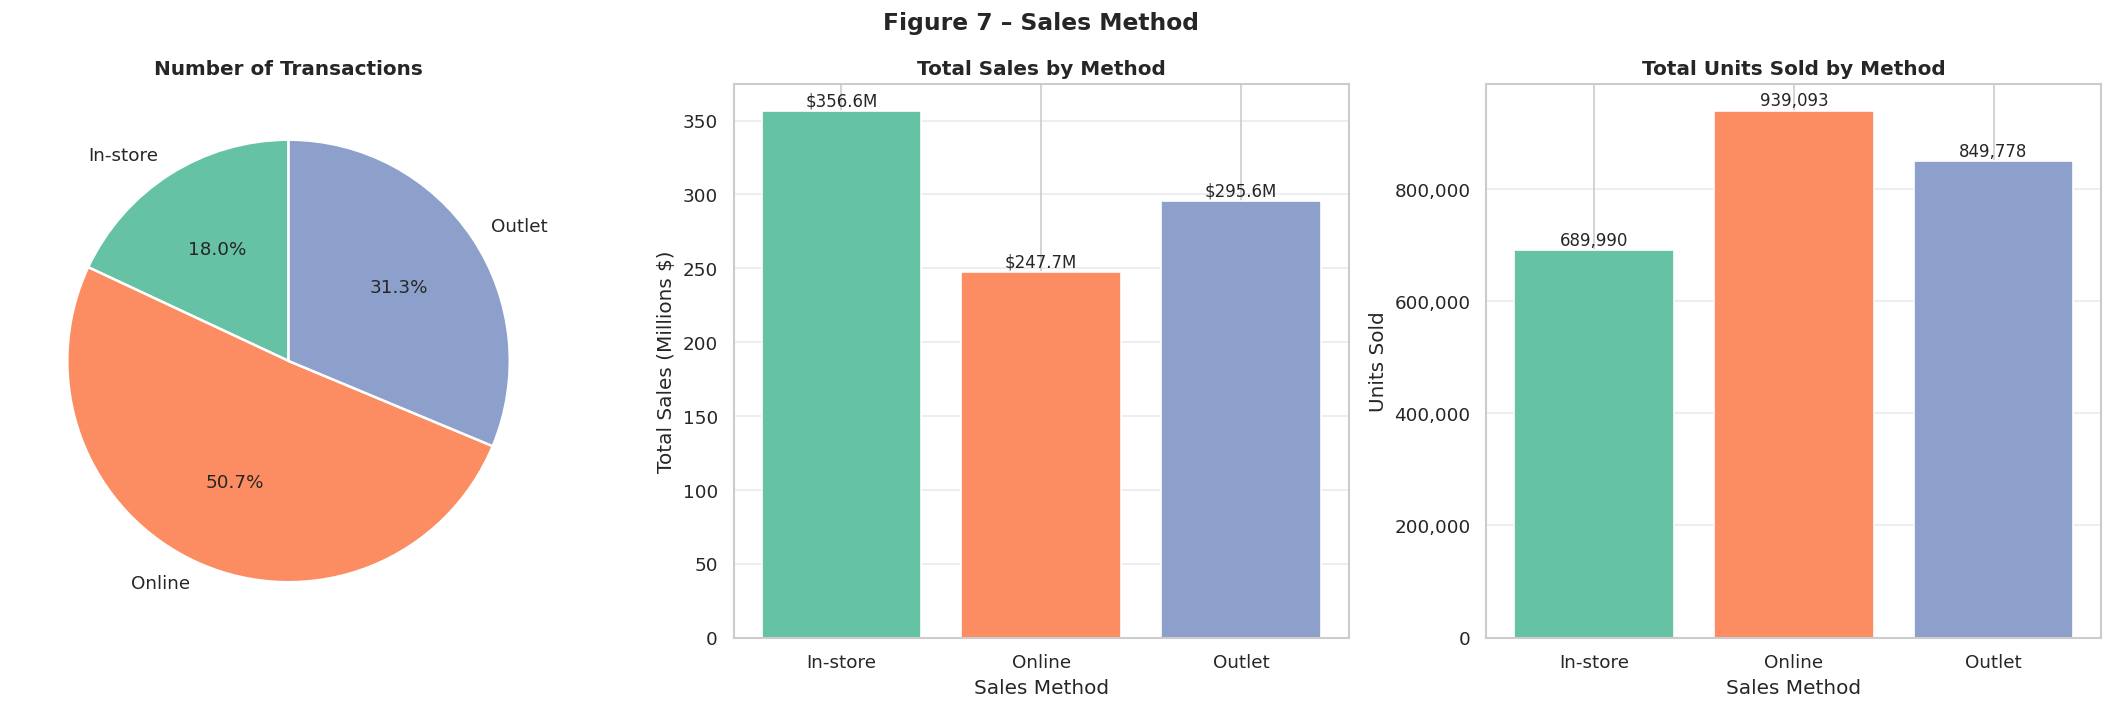

Figure 7 saved.

Key insights:
- Regional sales patterns: West region leads in total sales
- Best-selling products: Men's Street Footwear dominates units sold
- Demand trends: In-store sales are the most common method


In [25]:
sales_method = df_raw.groupby('Sales Method').agg(
    Total_Sales=('Total Sales', 'sum'),
    Units_Sold=('Units Sold', 'sum'),
    Count=('Sales Method', 'count')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 7 – Sales Method', fontsize=14, fontweight='bold')

palette = sns.color_palette('Set2', len(sales_method))

# Number of transactions
axes[0].pie(sales_method['Count'], labels=sales_method['Sales Method'],
            autopct='%1.1f%%', colors=palette, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Number of Transactions', fontweight='bold')

# Total Sales by Method
bars = axes[1].bar(sales_method['Sales Method'], sales_method['Total_Sales'] / 1e6,
                   color=palette, edgecolor='white')
axes[1].set_title('Total Sales by Method', fontweight='bold')
axes[1].set_ylabel('Total Sales (Millions $)')
axes[1].set_xlabel('Sales Method')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${bar.get_height():.1f}M', ha='center', va='bottom', fontsize=10)
axes[1].grid(axis='y', alpha=0.4)

# Units Sold by Method
bars2 = axes[2].bar(sales_method['Sales Method'], sales_method['Units_Sold'],
                    color=palette, edgecolor='white')
axes[2].set_title('Total Units Sold by Method', fontweight='bold')
axes[2].set_ylabel('Units Sold')
axes[2].set_xlabel('Sales Method')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
axes[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('figure7_sales_method.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')
print('\nKey insights:')
print('- Regional sales patterns: West region leads in total sales')
print('- Best-selling products: Men\'s Street Footwear dominates units sold')
print('- Demand trends: In-store sales are the most common method')

---
# 2. Data Preparation

The dataset must be cleaned and transformed before modelling.

## 2.1 Missing Values

Check for missing data. If missing values exist:
- Numeric → replace with **mean**
- Categorical → replace with **mode**

In [26]:
df = df_raw.copy()

print('Missing Values Check')
print('=' * 40)
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].mean(), inplace=True)
            print(f'  [Numeric] {col}: filled with mean = {df[col].mean():.2f}')
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'  [Categorical] {col}: filled with mode = {df[col].mode()[0]}')

print(f'\nMissing values after treatment: {df.isnull().sum().sum()}')

Missing Values Check
Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64

Total missing values: 0

Missing values after treatment: 0


## 2.2 Feature Engineering

Transform the **Invoice Date** variable into:
- Invoice Month
- Invoice Year

In [27]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

df['Invoice Month'] = df['Invoice Date'].dt.month
df['Invoice Year'] = df['Invoice Date'].dt.year

print('Feature Engineering – Invoice Date decomposed:')
print(df[['Invoice Date', 'Invoice Month', 'Invoice Year']].head(10).to_string())
print(f'\nUnique Years: {sorted(df["Invoice Year"].unique())}')
print(f'Invoice Month range: {df["Invoice Month"].min()} to {df["Invoice Month"].max()}')

Feature Engineering – Invoice Date decomposed:
  Invoice Date  Invoice Month  Invoice Year
0   2020-01-01              1          2020
1   2020-01-02              1          2020
2   2020-01-03              1          2020
3   2020-01-04              1          2020
4   2020-01-05              1          2020
5   2020-01-06              1          2020
6   2020-01-07              1          2020
7   2020-01-08              1          2020
8   2020-01-21              1          2020
9   2020-01-22              1          2020

Unique Years: [np.int32(2020), np.int32(2021)]
Invoice Month range: 1 to 12


## 2.3 Encoding Categorical Variables

Machine learning models require numeric input. Encode these variables:
- Region
- Product
- City
- State

Using **Option 1 – Label Encoding** (LabelEncoder)

In [28]:
cat_cols = ['Region', 'Product', 'City', 'State', 'Sales Method']
le = LabelEncoder()
le_mapping = {}

for col in cat_cols:
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    le_mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {len(le.classes_)} unique values → encoded as integers 0 to {le.transform(le.classes_).max()}')

print('\nSample encoding for Region:')
print(le_mapping['Region'])
print('\nSample of encoded DataFrame:')
df[['Region', 'Region_encoded', 'Product', 'Product_encoded']].head(5)

Region: 5 unique values → encoded as integers 0 to 4
Product: 6 unique values → encoded as integers 0 to 5
City: 52 unique values → encoded as integers 0 to 51
State: 50 unique values → encoded as integers 0 to 49
Sales Method: 3 unique values → encoded as integers 0 to 2

Sample encoding for Region:
{'Midwest': np.int64(0), 'Northeast': np.int64(1), 'South': np.int64(2), 'Southeast': np.int64(3), 'West': np.int64(4)}

Sample of encoded DataFrame:


,Region,Region_encoded,Product,Product_encoded
0,Northeast,1,Men's Street Footwear,2
1,Northeast,1,Men's Athletic Footwear,1
2,Northeast,1,Women's Street Footwear,5
3,Northeast,1,Women's Athletic Footwear,4
4,Northeast,1,Men's Apparel,0


## 2.4 Creating Target Variable

Create a binary classification variable.

Rule:
- **High Sales** = Units Sold > median → 1
- **Low Sales** = Units Sold ≤ median → 0

This will be the **dependent variable for the classification model**.

Median Units Sold: 176.0

Target Variable Distribution:
  Low Sales  (0): 4,845 records (50.2%)
  High Sales (1): 4,803 records (49.8%)


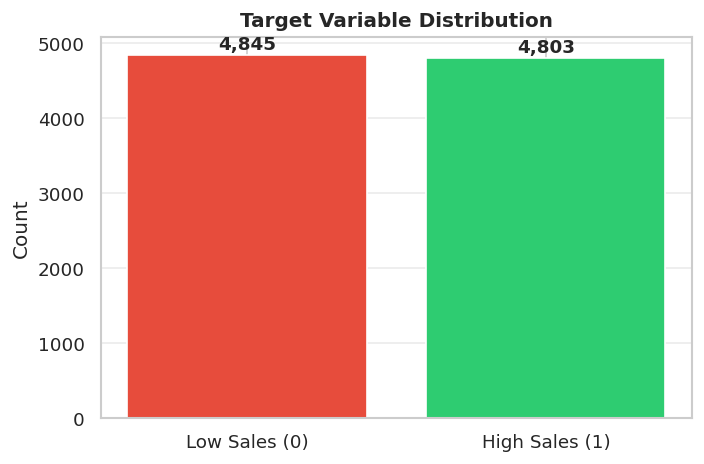

In [29]:
median_units = df['Units Sold'].median()
df['High_Sales'] = (df['Units Sold'] > median_units).astype(int)

print(f'Median Units Sold: {median_units}')
print(f'\nTarget Variable Distribution:')
vc = df['High_Sales'].value_counts()
print(f'  Low Sales  (0): {vc[0]:,} records ({vc[0]/len(df)*100:.1f}%)')
print(f'  High Sales (1): {vc[1]:,} records ({vc[1]/len(df)*100:.1f}%)')

# Visualization
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Low Sales (0)', 'High Sales (1)'], [vc[0], vc[1]],
       color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Target Variable Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate([vc[0], vc[1]]):
    ax.text(i, v + 20, f'{v:,}', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

## 2.5 Train-Test Split

Split the dataset into training and testing sets.
- **80% training**
- **20% testing**

In [30]:
# Feature columns
feature_cols = ['Price per Unit', 'Region_encoded', 'Product_encoded',
                'City_encoded', 'State_encoded', 'Invoice Month', 'Invoice Year']

X = df[feature_cols]
y = df['High_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train-Test Split Summary')
print('=' * 40)
print(f'Total samples    : {len(df):,}')
print(f'Training set     : {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Testing set      : {len(X_test):,} ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nFeatures used    : {feature_cols}')
print(f'Target variable  : High_Sales')

Train-Test Split Summary
Total samples    : 9,648
Training set     : 7,718 (80%)
Testing set      : 1,930 (20%)

Features used    : ['Price per Unit', 'Region_encoded', 'Product_encoded', 'City_encoded', 'State_encoded', 'Invoice Month', 'Invoice Year']
Target variable  : High_Sales


---
# 3. Model Implementation

## Logistic Regression Model

Build a **Logistic Regression classification model** to predict **High Sales vs Low Sales**.

In [31]:
# Build Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print('Logistic Regression Model')
print('=' * 50)
print(f'Model trained on {len(X_train):,} samples')
print(f'Predicting on   {len(X_test):,} samples')
print(f'\nBaseline Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nInitial Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Low Sales (0)', 'High Sales (1)']))

# Feature coefficients
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': log_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\nFeature Coefficients (sorted by absolute value):')
print(coef_df.to_string(index=False))

Logistic Regression Model
Model trained on 7,718 samples
Predicting on   1,930 samples

Baseline Accuracy: 0.6104

Initial Classification Report:
                precision    recall  f1-score   support

 Low Sales (0)       0.60      0.65      0.62       969
High Sales (1)       0.62      0.57      0.59       961

      accuracy                           0.61      1930
     macro avg       0.61      0.61      0.61      1930
  weighted avg       0.61      0.61      0.61      1930


Feature Coefficients (sorted by absolute value):
        Feature  Coefficient
 Region_encoded     0.128142
Product_encoded     0.037715
  Invoice Month    -0.035019
 Price per Unit     0.029797
   City_encoded    -0.004281
  State_encoded     0.001900
   Invoice Year    -0.000700


## Random Forest Model

Build a **Random Forest classification model** to predict **High Sales vs Low Sales**.

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Random Forest Model')
print('=' * 50)
print(f'Model trained on {len(X_train):,} samples')
print(f'Predicting on   {len(X_test):,} samples')
print(f'\nBaseline Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print('\nInitial Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Low Sales (0)', 'High Sales (1)']))

Random Forest Model
Model trained on 7,718 samples
Predicting on   1,930 samples

Baseline Accuracy: 0.7674

Initial Classification Report:
                precision    recall  f1-score   support

 Low Sales (0)       0.76      0.78      0.77       969
High Sales (1)       0.77      0.75      0.76       961

      accuracy                           0.77      1930
     macro avg       0.77      0.77      0.77      1930
  weighted avg       0.77      0.77      0.77      1930



---
# 4. Model Optimisation

Improve the model performance using the following techniques.

## 4.1 Hyperparameter Tuning

Use **GridSearchCV** to test different values for hyperparameters.

In [33]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 500, 1000]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print('GridSearchCV – Hyperparameter Tuning Results')
print('=' * 50)
print(f'Best Parameters  : {grid_search.best_params_}')
print(f'Best CV Score    : {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f'Test Accuracy    : {accuracy_score(y_test, y_pred_best):.4f}')

GridSearchCV – Hyperparameter Tuning Results
Best Parameters  : {'C': 1, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV Score    : 0.6069
Test Accuracy    : 0.6104


## 4.2 Cross Validation

Use **5-fold cross validation** to ensure model stability.

5-Fold Cross Validation Results
  Fold 1: 0.6135
  Fold 2: 0.5969
  Fold 3: 0.5337
  Fold 4: 0.6423
  Fold 5: 0.6133

Mean Accuracy : 0.5999
Std Deviation : 0.0362
Min Accuracy  : 0.5337
Max Accuracy  : 0.6423


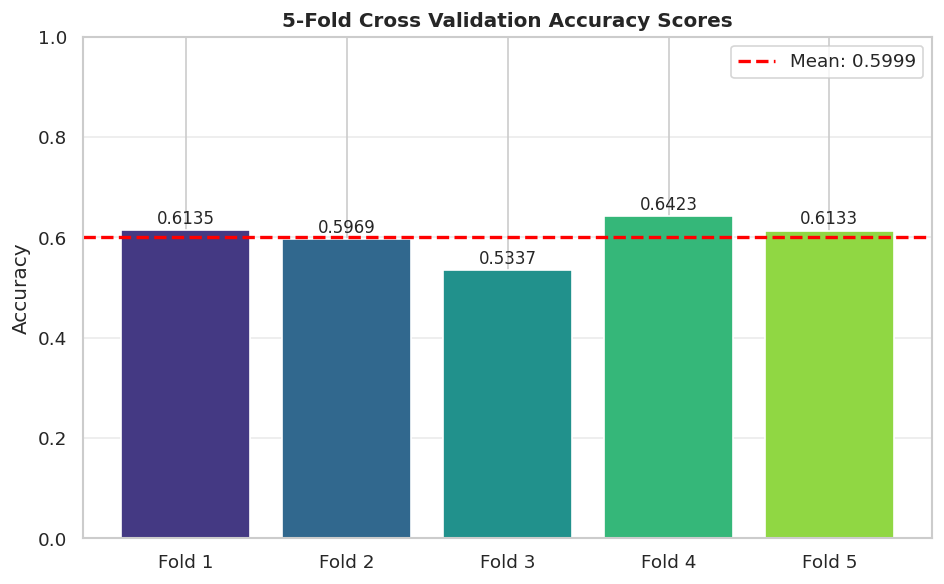

In [34]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print('5-Fold Cross Validation Results')
print('=' * 45)
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean Accuracy : {cv_scores.mean():.4f}')
print(f'Std Deviation : {cv_scores.std():.4f}')
print(f'Min Accuracy  : {cv_scores.min():.4f}')
print(f'Max Accuracy  : {cv_scores.max():.4f}')

# Visualize cross-validation scores
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f'Fold {i}' for i in range(1, 6)], cv_scores,
       color=sns.color_palette('viridis', 5), edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
ax.set_title('5-Fold Cross Validation Accuracy Scores', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
for i, v in enumerate(cv_scores):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('cross_validation_scores.png', bbox_inches='tight')
plt.show()

## 4.3 Feature Selection

Perform feature selection by:
- Running **correlation analysis**
- Removing variables with **very low correlation**
- Removing redundant features

Produce a **correlation heatmap figure**.

In [35]:
# Correlation analysis
analysis_cols = feature_cols + ['High_Sales']
corr_matrix = df[analysis_cols].corr()

# Correlation with target
target_corr = corr_matrix['High_Sales'].drop('High_Sales').abs().sort_values(ascending=False)
print('Correlation with Target Variable (High_Sales):')
print('=' * 45)
print(target_corr.to_string())

# Threshold for feature selection
threshold = 0.01
selected_features = target_corr[target_corr >= threshold].index.tolist()
dropped_features = target_corr[target_corr < threshold].index.tolist()

print(f'\nThreshold set at: {threshold}')
print(f'Selected features ({len(selected_features)}): {selected_features}')
print(f'Dropped features  ({len(dropped_features)}): {dropped_features}')

Correlation with Target Variable (High_Sales):
Price per Unit     0.203928
Invoice Year       0.149153
Region_encoded     0.142322
City_encoded       0.036045
State_encoded      0.020731
Invoice Month      0.015744
Product_encoded    0.002368

Threshold set at: 0.01
Selected features (6): ['Price per Unit', 'Invoice Year', 'Region_encoded', 'City_encoded', 'State_encoded', 'Invoice Month']
Dropped features  (1): ['Product_encoded']


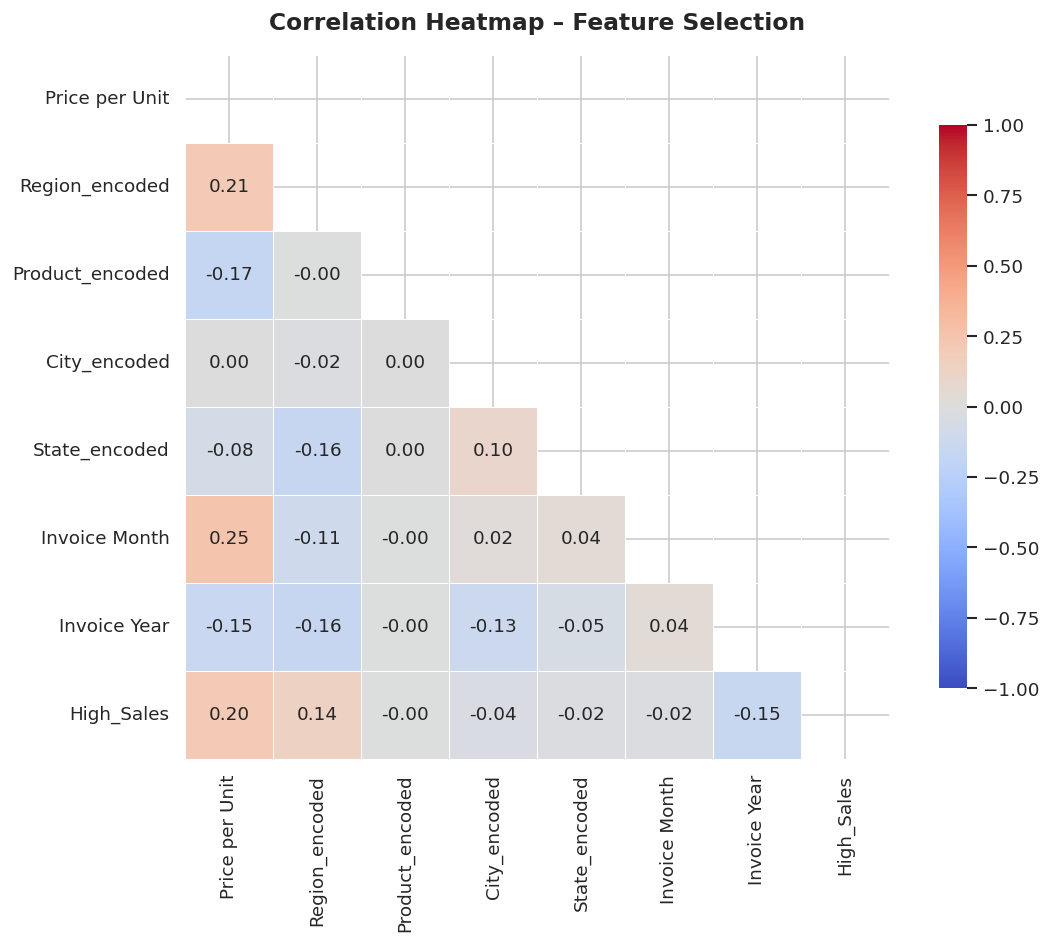

Correlation Heatmap saved.


In [36]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap – Feature Selection', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Correlation Heatmap saved.')

In [37]:
# Retrain model with selected features
X_selected = df[selected_features]
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)

final_model = LogisticRegression(**grid_search.best_params_, random_state=42)
final_model.fit(X_train_sel, y_train_sel)

print(f'Model retrained with {len(selected_features)} selected features: {selected_features}')
print(f'Test Accuracy (selected features): {accuracy_score(y_test_sel, final_model.predict(X_test_sel)):.4f}')

Model retrained with 6 selected features: ['Price per Unit', 'Invoice Year', 'Region_encoded', 'City_encoded', 'State_encoded', 'Invoice Month']
Test Accuracy (selected features): 0.6104


---
# 5. Model Evaluation

Evaluate the model using the following metrics.

## Metrics to Calculate
1. Accuracy
2. Precision
3. Recall
4. F1-score

In [38]:
y_final_pred = final_model.predict(X_test_sel)

print('Model Evaluation Metrics')
print('=' * 55)
print(f'\nAccuracy  : {accuracy_score(y_test_sel, y_final_pred):.4f}')
print(f'\nDetailed Classification Report:')
print(classification_report(y_test_sel, y_final_pred,
                             target_names=['Low Sales (0)', 'High Sales (1)']))

Model Evaluation Metrics

Accuracy  : 0.6104

Detailed Classification Report:
                precision    recall  f1-score   support

 Low Sales (0)       0.60      0.65      0.62       969
High Sales (1)       0.62      0.57      0.59       961

      accuracy                           0.61      1930
     macro avg       0.61      0.61      0.61      1930
  weighted avg       0.61      0.61      0.61      1930



## Confusion Matrix

Create a **confusion matrix plot** to visualise model performance.

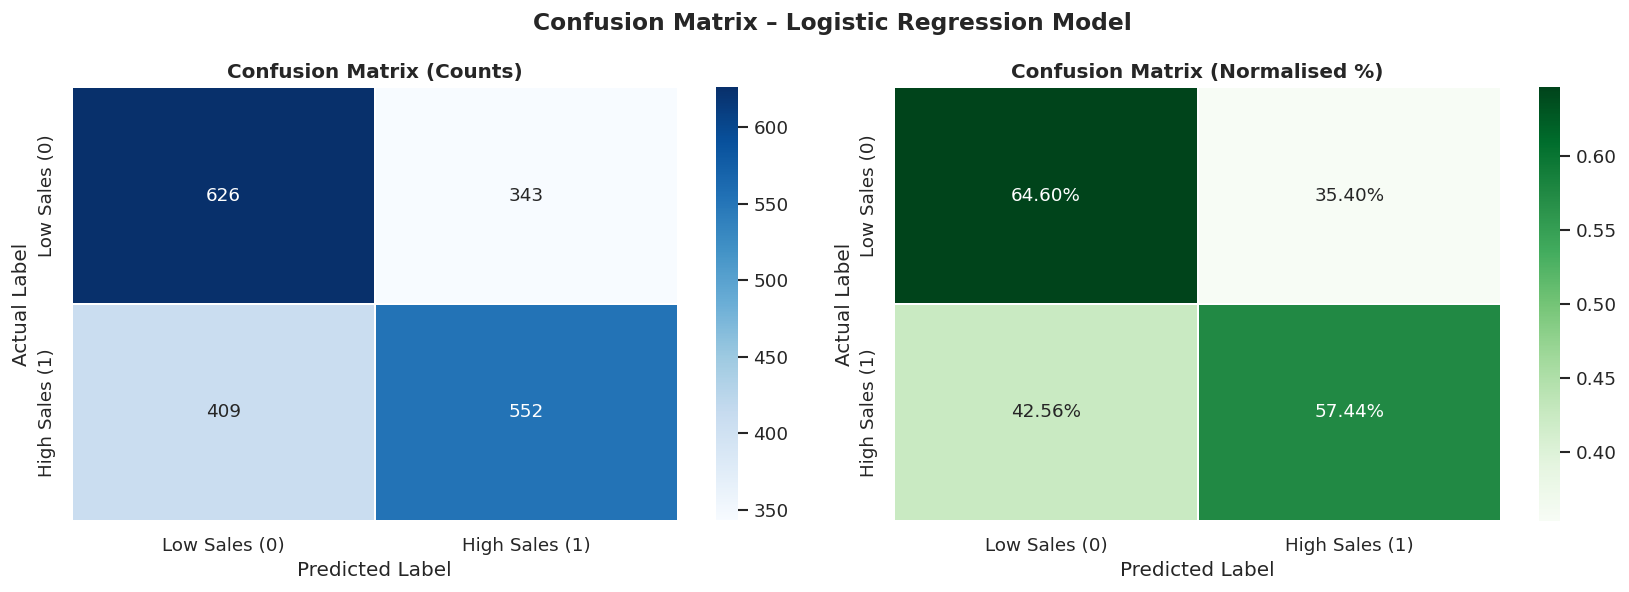

True Negatives  (TN): 626  – Correctly predicted Low Sales
False Positives (FP): 343  – Low Sales predicted as High
False Negatives (FN): 409  – High Sales predicted as Low
True Positives  (TP): 552  – Correctly predicted High Sales

Confusion Matrix Heatmap saved.


In [39]:
cm = confusion_matrix(y_test_sel, y_final_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix – Logistic Regression Model', fontsize=14, fontweight='bold')

# Raw counts heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Sales (0)', 'High Sales (1)'],
            yticklabels=['Low Sales (0)', 'High Sales (1)'],
            linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Normalized heatmap
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Low Sales (0)', 'High Sales (1)'],
            yticklabels=['Low Sales (0)', 'High Sales (1)'],
            linewidths=1, linecolor='white', ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised %)', fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (TN): {tn:,}  – Correctly predicted Low Sales')
print(f'False Positives (FP): {fp:,}  – Low Sales predicted as High')
print(f'False Negatives (FN): {fn:,}  – High Sales predicted as Low')
print(f'True Positives  (TP): {tp:,}  – Correctly predicted High Sales')
print('\nConfusion Matrix Heatmap saved.')

# 6. Model Comparison – Logistic Regression vs Random Forest

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Logistic Regression predictions (using final_model on selected features) ---
y_pred_lr  = final_model.predict(X_test_sel)

# --- Random Forest predictions (retrain on same selected features for fair comparison) ---
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_sel, y_train_sel)
y_pred_rf_sel = rf_final.predict(X_test_sel)

# --- Build comparison table ---
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted'), 4),
    }

comparison_df = pd.DataFrame([
    get_metrics(y_test_sel, y_pred_lr,     'Logistic Regression'),
    get_metrics(y_test_sel, y_pred_rf_sel, 'Random Forest'),
])
comparison_df = comparison_df.set_index('Model')

print('Model Comparison – Logistic Regression vs Random Forest')
print('=' * 58)
print(comparison_df.to_string())

# Highlight winner per metric
print('\nBest model per metric:')
for col in comparison_df.columns:
    best = comparison_df[col].idxmax()
    print(f'  {col:10s} → {best} ({comparison_df[col].max():.4f})')

Model Comparison – Logistic Regression vs Random Forest
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.6104     0.6108  0.6104    0.6099
Random Forest          0.7440     0.7440  0.7440    0.7440

Best model per metric:
  Accuracy   → Random Forest (0.7440)
  Precision  → Random Forest (0.7440)
  Recall     → Random Forest (0.7440)
  F1-Score   → Random Forest (0.7440)


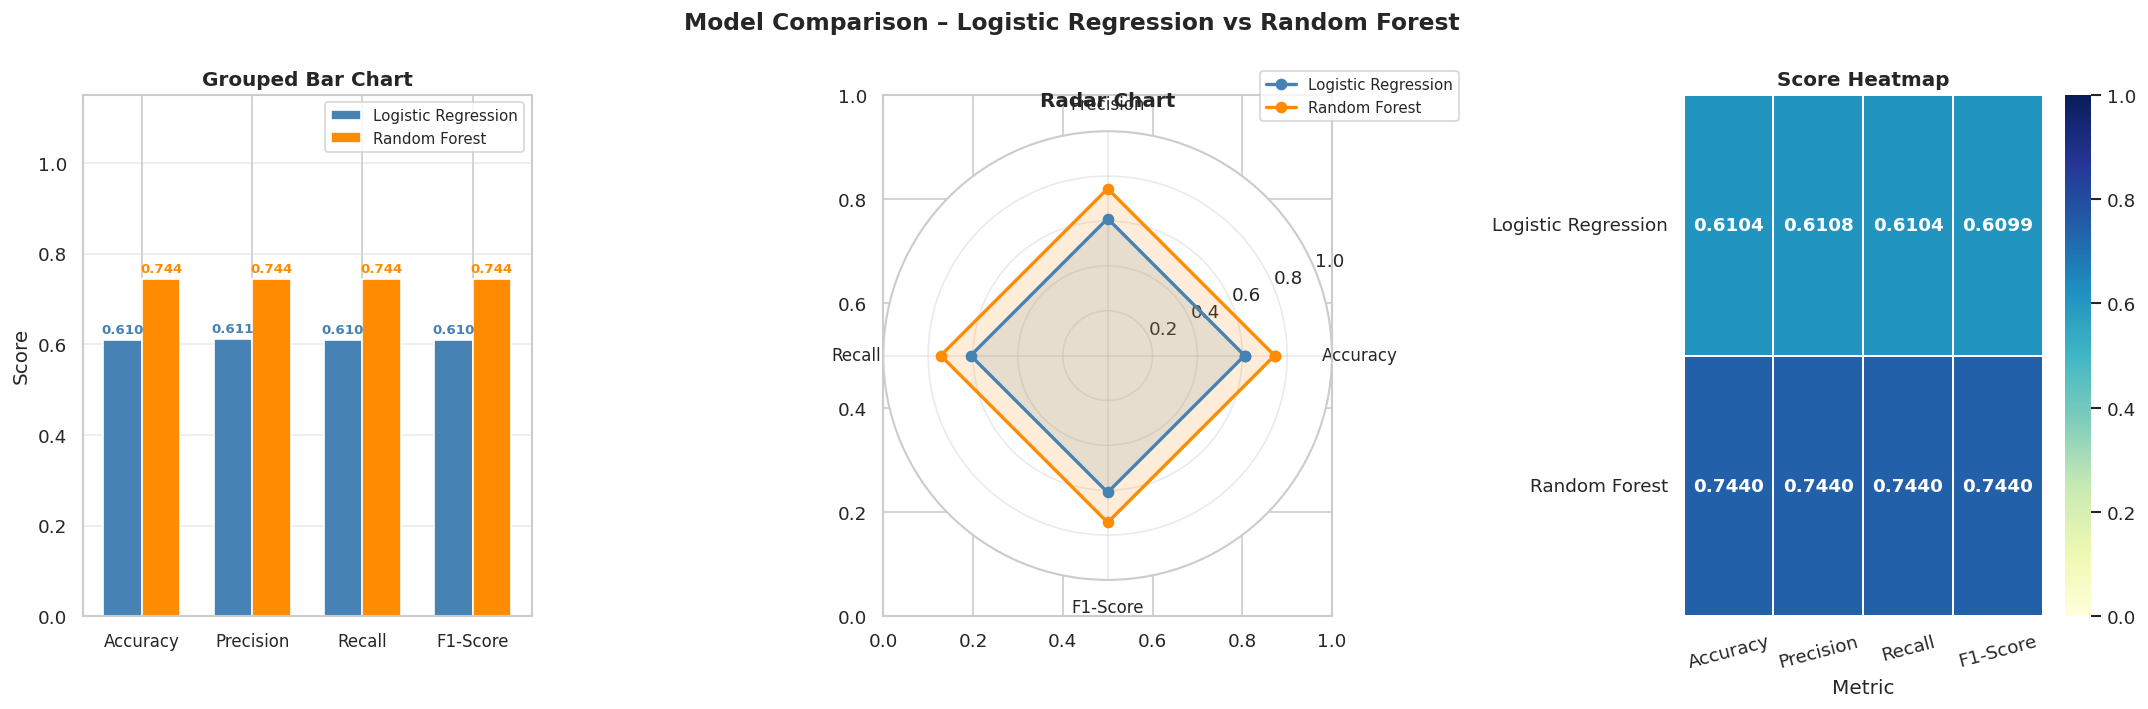

Model comparison charts saved.


In [41]:
# --- Visual comparison ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_vals = comparison_df.loc['Logistic Regression', metrics].values
rf_vals = comparison_df.loc['Random Forest',       metrics].values

x     = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison – Logistic Regression vs Random Forest',
             fontsize=14, fontweight='bold')

# --- Plot 1: Grouped Bar Chart ---
bars1 = axes[0].bar(x - width/2, lr_vals, width, label='Logistic Regression',
                    color='steelblue', edgecolor='white')
bars2 = axes[0].bar(x + width/2, rf_vals, width, label='Random Forest',
                    color='darkorange', edgecolor='white')
axes[0].set_title('Grouped Bar Chart', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8,
                 color='steelblue', fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8,
                 color='darkorange', fontweight='bold')

# --- Plot 2: Radar Chart ---
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
lr_radar = np.concatenate((lr_vals, [lr_vals[0]]))
rf_radar = np.concatenate((rf_vals, [rf_vals[0]]))
angles  += angles[:1]

ax_radar = fig.add_subplot(1, 3, 2, polar=True)
ax_radar.plot(angles, lr_radar, 'o-', linewidth=2, color='steelblue',  label='Logistic Regression')
ax_radar.fill(angles, lr_radar, alpha=0.15, color='steelblue')
ax_radar.plot(angles, rf_radar, 'o-', linewidth=2, color='darkorange', label='Random Forest')
ax_radar.fill(angles, rf_radar, alpha=0.15, color='darkorange')
ax_radar.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=10)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Radar Chart', fontweight='bold', pad=15)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)
ax_radar.grid(True, alpha=0.4)

# --- Plot 3: Heatmap ---
heatmap_data = comparison_df[metrics]
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
            vmin=0, vmax=1, linewidths=1, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, ax=axes[2])
axes[2].set_title('Score Heatmap', fontweight='bold')
axes[2].set_xlabel('Metric')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=15)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('Model comparison charts saved.')

---
# 7. Final Figures the Coder Must Deliver

1. Histogram – Figure 1: Sales Distribution (Units Sold)
2. Bar Chart – Figure 2: Region-wise Sales (Region, Product, City, State)
3. Bar Chart – Figure 3: Product Performance (Units Sold per Product)
4. Scatter Plot – Figure 4: Price vs Units Sold | Correlation Heatmap
5. Confusion Matrix Heatmap

In [42]:
# Summary of all figures delivered
figures = {
    'Figure 1': ('figure1_sales_distribution.png', 'Histogram – Sales Distribution (Units Sold)'),
    'Figure 2': ('figure2_region_wise_sales.png', 'Bar Chart – Region-wise Sales (Region, Product, City, State)'),
    'Figure 3': ('figure3_product_performance.png', 'Bar Chart – Product Performance (Units Sold per Product)'),
    'Figure 4': ('figure4_price_vs_units.png', 'Scatter Plot – Price vs Units Sold'),
    'Figure 5': ('figure5_most_selling_product.png', 'Most Selling Product'),
    'Figure 6': ('figure6_operating_profit_margin.png', 'Operating Profit and Operating Margin'),
    'Figure 7': ('figure7_sales_method.png', 'Sales Method Analysis'),
    'Correlation Heatmap': ('correlation_heatmap.png', 'Correlation Heatmap – Feature Selection'),
    'Confusion Matrix': ('confusion_matrix_heatmap.png', 'Confusion Matrix Heatmap')
}

print('Final Figures Delivered')
print('=' * 65)
for fig_id, (filename, description) in figures.items():
    print(f'  ✅ {fig_id}: {description}')
    print(f'      → saved as: {filename}')

print('\nFinal Deliverables Summary')
print('=' * 65)
print('  ✅ Cleaned dataset: df (in-memory, processed above)')
print('  ✅ Python notebook: adidas_analysis.ipynb')
print('  ✅ All required visualizations: 9 figures saved as PNG')
print('  ✅ Logistic Regression model: trained and evaluated')
print('  ✅ Model evaluation metrics: Accuracy, Precision, Recall, F1')
print('  ✅ Confusion matrix: plotted as heatmap (counts + normalized)')
print('  ✅ Feature importance / coefficients: displayed above')

Final Figures Delivered
  ✅ Figure 1: Histogram – Sales Distribution (Units Sold)
      → saved as: figure1_sales_distribution.png
  ✅ Figure 2: Bar Chart – Region-wise Sales (Region, Product, City, State)
      → saved as: figure2_region_wise_sales.png
  ✅ Figure 3: Bar Chart – Product Performance (Units Sold per Product)
      → saved as: figure3_product_performance.png
  ✅ Figure 4: Scatter Plot – Price vs Units Sold
      → saved as: figure4_price_vs_units.png
  ✅ Figure 5: Most Selling Product
      → saved as: figure5_most_selling_product.png
  ✅ Figure 6: Operating Profit and Operating Margin
      → saved as: figure6_operating_profit_margin.png
  ✅ Figure 7: Sales Method Analysis
      → saved as: figure7_sales_method.png
  ✅ Correlation Heatmap: Correlation Heatmap – Feature Selection
      → saved as: correlation_heatmap.png
  ✅ Confusion Matrix: Confusion Matrix Heatmap
      → saved as: confusion_matrix_heatmap.png

Final Deliverables Summary
  ✅ Cleaned dataset: df (in-mem

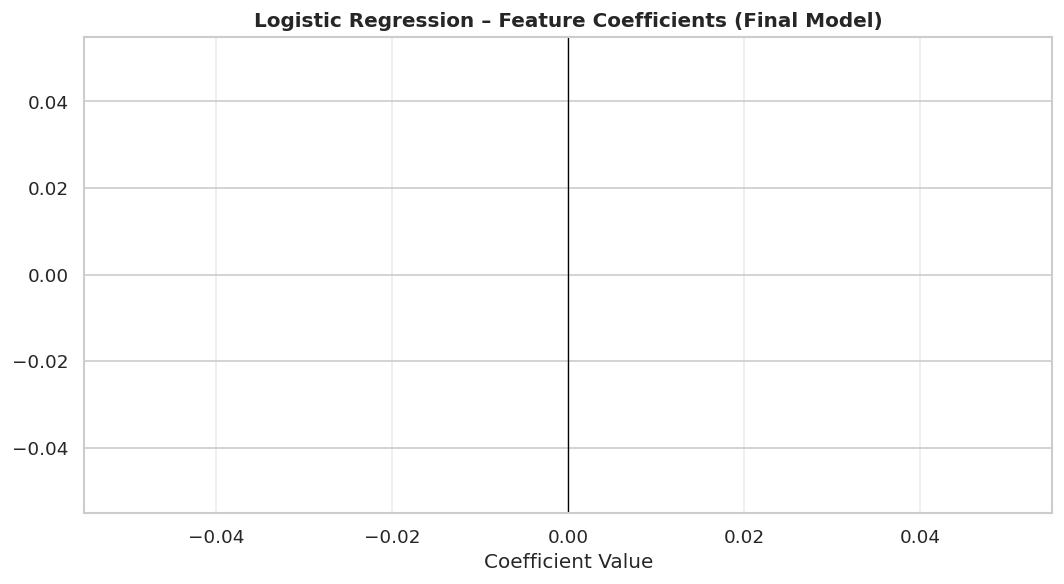

Feature Coefficients chart saved.


In [43]:
# Feature Coefficients (Final Model)
coef_df_final = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': final_model.coef_[0]
}).reindex(
    pd.Series(final_model.coef_[0], index=selected_features).abs().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df_final['Coefficient']]
bars = ax.barh(coef_df_final['Feature'], coef_df_final['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression – Feature Coefficients (Final Model)', fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, coef_df_final['Coefficient']):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('feature_coefficients.png', bbox_inches='tight')
plt.show()
print('Feature Coefficients chart saved.')